Title: CESM_LE_Analysis_PP.ipynb

Purpose: Look at which seasons produce many VRES events and high mean seasonal RL

Author: Onno Nennecke on 16.06.2026 Modified: 17.06.2026

Input data: 

- Model output: model_output_all.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
- VRES data
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv'

Output data:

- List of ESM_run and seasons
    - These files lie here: /home/onennecke/extreme_seasons.csv

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ds.load()

# Filter for CESM2_LE2 runs
ts_datasets = ds.where(ds.ESM_run.str.contains('CESM2_LE2'), drop=True) 
ts_datasets.load()


# Add a season coordinate to the dataset
not_winter = np.repeat(0, 183)

season = np.concatenate(
    [np.repeat(1, 90)] +
    [arr
        for i in range(2, 11)
        for arr in (not_winter, np.repeat(i, 182))
    ] +
    [not_winter, np.repeat(11, 92)]
)

ts_datasets= ts_datasets.assign_coords(season=("time", season))


In [15]:
ts_seasonal_mean = ts_datasets.groupby('season').mean('time')
ts_seasonal_mean = ts_seasonal_mean['Residual_load'][ts_seasonal_mean.season != 0]
# ts_seasonal_mean

In [ ]:
df = ts_seasonal_mean.to_dataframe(name="Residual_load").reset_index()
# Rename Residual_load to Seas_mean_RL
df = df.rename(columns={'Residual_load': 'Seas_mean_RL'})

# Add a column for the years corresponding to each season
season_years = []
for season in df['season']:
    season_years.append(f"{13 + season}/{13+ season+1}")
df['Season_Year'] = season_years
df

# Remove columns crs, gridtype, ESM, country, period
df = df.drop(columns=['crs', 'gridtype', 'ESM', 'country', 'period'])

# Remove all entries with season 1 and 11 (half winter seasons)
df = df[df['season'] != 1]
df = df[df['season'] != 11]
df['index_col'] = df['ESM_run'] + '_' + df['Season_Year']

df = df.drop(columns=['ESM_run'])

# Sort the df by Seas_mean_RL
df_sorted = df.sort_values(by="Seas_mean_RL", ascending=False)
df_sorted[0:10]

,season,run,Seas_mean_RL,Season_Year,index_col
473,5,LE2-1281_014,1186.983690,18/19,CESM2_LE2-1281_014_18/19
588,6,LE2-1301_009,1178.078841,19/20,CESM2_LE2-1301_009_19/20
532,6,LE2-1231_013,1173.946744,19/20,CESM2_LE2-1231_013_19/20
905,10,LE2-1051_003,1165.084698,23/24,CESM2_LE2-1051_003_23/24
733,8,LE2-1231_014,1164.666054,21/22,CESM2_LE2-1231_014_21/22
405,5,LE2-1051_003,1159.427814,18/19,CESM2_LE2-1051_003_18/19
516,6,LE2-1161_009,1159.304789,19/20,CESM2_LE2-1161_009_19/20
333,4,LE2-1231_014,1156.331351,17/18,CESM2_LE2-1231_014_17/18
961,10,LE2-1281_002,1156.206856,23/24,CESM2_LE2-1281_002_23/24
682,7,LE2-1301_003,1152.206094,20/21,CESM2_LE2-1301_003_20/21


### Load VRES event data

In [17]:
# Function to add a winter season column
def add_winter_season_column(df):
    # Ensure 'date_start' is in datetime format
    df['date_start'] = pd.to_datetime(df['date_start'])
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    
    # Apply the function to create a new 'winter_season' column
    df['winter_season'] = df['date_start'].apply(get_winter_season)
    return df

In [18]:
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = add_winter_season_column(LEE_dat)
LEE_dat['index_col'] = LEE_dat['ESM_run'] + '_' + LEE_dat['winter_season']

LEE_CESM2_LE2 = LEE_dat[LEE_dat['ESM_run'].str.contains('CESM2_LE2')]

LEE_CESM2_LE2 = LEE_CESM2_LE2[LEE_CESM2_LE2['winter_season'] != '14/15']
LEE_CESM2_LE2 = LEE_CESM2_LE2[LEE_CESM2_LE2['winter_season'] != '24/25']

In [19]:
# Group by 'winter_season' and ESM_run and calculate the number of entries for each group
seasonal_counts = LEE_CESM2_LE2.groupby(['index_col']).size().reset_index(name='VRES_count')
seasonal_counts_sorted = seasonal_counts.sort_values(by='VRES_count', ascending=False)
seasonal_counts_sorted

,index_col,VRES_count
600,CESM2_LE2-1281_007_21/22,53
344,CESM2_LE2-1231_019_17/18,49
245,CESM2_LE2-1231_008_17/18,48
660,CESM2_LE2-1281_014_18/19,48
148,CESM2_LE2-1161_009_19/20,48
...,...,...
537,CESM2_LE2-1251_020_21/22,2
881,CESM2_LE2-1301_018_23/24,2
205,CESM2_LE2-1231_003_22/23,1
115,CESM2_LE2-1121_007_22/23,1


### Check if these metrics agree

In [20]:
# Join LEE_CESM2_LE2 and df on 'index_col'
merged_df = pd.merge(seasonal_counts, df, on='index_col', how='inner')
merged_df

,index_col,VRES_count,season,run,Seas_mean_RL,Season_Year
0,CESM2_LE2-1001_001_15/16,20,2,LE2-1001_001,974.544574,15/16
1,CESM2_LE2-1001_001_16/17,29,3,LE2-1001_001,1066.309857,16/17
2,CESM2_LE2-1001_001_17/18,11,4,LE2-1001_001,1043.373618,17/18
3,CESM2_LE2-1001_001_18/19,27,5,LE2-1001_001,1015.075029,18/19
4,CESM2_LE2-1001_001_19/20,26,6,LE2-1001_001,995.526694,19/20
...,...,...,...,...,...,...
895,CESM2_LE2-1301_020_19/20,25,6,LE2-1301_020,1085.875193,19/20
896,CESM2_LE2-1301_020_20/21,21,7,LE2-1301_020,1037.127795,20/21
897,CESM2_LE2-1301_020_21/22,25,8,LE2-1301_020,1035.285425,21/22
898,CESM2_LE2-1301_020_22/23,27,9,LE2-1301_020,1056.234436,22/23


In [25]:
seas_top_20 = seasonal_counts_sorted[0:20]
df_top_20 = df_sorted[0:20]
# Combine both top 20 after one another
extreme_seasons = pd.concat([seas_top_20, df_top_20], ignore_index=True)
extreme_seasons

extreme_seasons_fin = merged_df[merged_df['index_col'].isin(extreme_seasons['index_col'])]
extreme_seasons_fin

# Reorder columns in extreme_seasons_fin
extreme_seasons_fin = extreme_seasons_fin[['index_col', 'run', 'season', 'Season_Year', 'Seas_mean_RL', 'VRES_count']]
# extreme_seasons_fin

In [32]:
# Save extreme_seasons_fin to a csv file
extreme_seasons_fin.to_csv('/home/onennecke/extreme_seasons.csv', index=False)

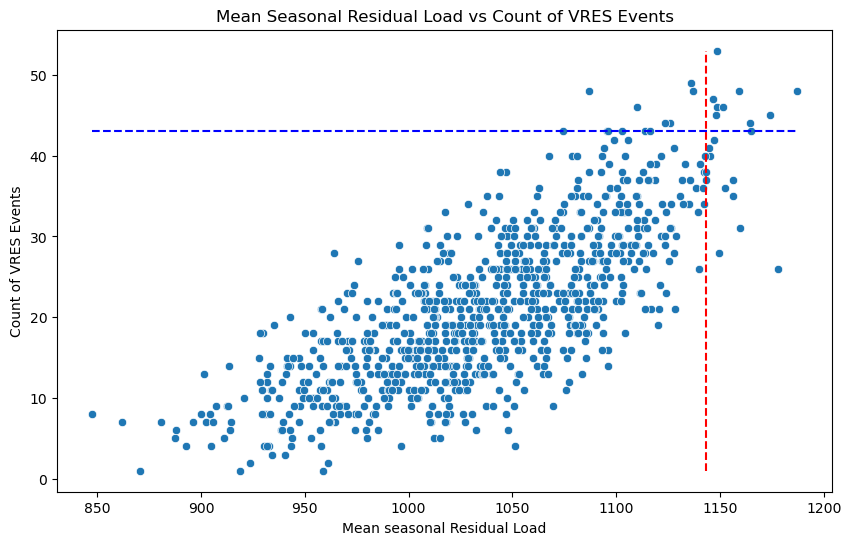

In [30]:
# Plot Seas_mean_RL vs VRES_count
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='Seas_mean_RL', y='VRES_count')
plt.vlines(x=df_top_20['Seas_mean_RL'].min(), ymin=merged_df['VRES_count'].min(), ymax=merged_df['VRES_count'].max(), color='red', linestyle='--')
plt.hlines(y=seas_top_20['VRES_count'].min(), xmin=merged_df['Seas_mean_RL'].min(), xmax=merged_df['Seas_mean_RL'].max(), color='blue', linestyle='--')
plt.title('Mean Seasonal Residual Load vs Count of VRES Events')
plt.xlabel('Mean seasonal Residual Load')
plt.ylabel('Count of VRES Events')
plt.show()

In [23]:
len(extreme_seasons_fin)

31